# Eigenvalues, Eigenvectors, SVD, PCA, Optimization, and Low-Rank Structure for Machine Learning


This note is designed to learn elemntary concepts in linear algebra for machine learning, representation learning, deep learning, and numerical optimization

## Roadmap

1. Eigenvalues and eigenvectors  
2. Why diagonalization works  
3. Coordinate changes and the meaning of $P^{-1}x$  
4. Worked diagonalization example  
5. When diagonalization fails  
6. Singular Value Decomposition (SVD)  
7. Comparison: eigendecomposition vs SVD  
8. PCA from covariance and from SVD  
9. Low-rank approximation and model compression  
10. Hessian eigenvalues and optimization in deep learning  
11. Solved exercises  
12. Further practice


In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)


# 1. Eigenvalues and eigenvectors

Most linear maps mix coordinates. A general transformation can:

- stretch
- compress
- rotate
- shear
- combine all of these

But an eigenvector is a special direction along which the map is simple:

- the direction is preserved
- only the length changes
- if $\lambda < 0$, the direction flips

In a mathematical formualtion, 
Let $A \in \mathbb{R}^{n \times n}$. A nonzero vector $v$ is an **eigenvector** of $A$ if

$Av = \lambda v$

for some scalar $\lambda \in \mathbb{R}$ or $\mathbb{C}$.  
The scalar $\lambda$ is the **eigenvalue** associated with $v$.

So eigenvectors are the directions in which the transformation reveals its internal structure.


# 2. Why eigenvectors simplify a transformation

Suppose $A$ has $n$ linearly independent eigenvectors $v_1,\dots,v_n$ with eigenvalues $\lambda_1,\dots,\lambda_n.$ Because these eigenvectors form a basis, every vector $x$ can be written as

$$x = c_1v_1 + c_2v_2 + \cdots + c_nv_n.$$

Now apply $A$:

$$Ax = A(c_1v_1 + \cdots + c_nv_n)$$

and by linearity,
$$Ax = c_1Av_1 + \cdots + c_nAv_n.$$

Since each $v_i$ is an eigenvector,

$$Av_i = \lambda_i v_i,$$

so

$$Ax = c_1\lambda_1v_1 + \cdots + c_n\lambda_n v_n.$$


## Key Insight

When we express a vector in the eigenvector basis, the transformation $ A$ acts in a very simple way:

- each coordinate $ v_i $ is scaled independently by $ \lambda_i $
- there is **no mixing between directions**
- the transformation becomes completely decoupled

In other words:

> In the eigenvector basis, a complicated linear transformation reduces to independent scaling along each axis.

---

## Deeper Interpretation

In standard coordinates, a matrix may mix components (e.g., turning an $x$-component into part of the $y$-direction).

But in the eigenvector basis:

- each direction evolves independently
- the transformation becomes predictable and structured

This is precisely why diagonalization works:

$$A = P D P^{-1}$$

because in the right coordinate system, the matrix is just a scaling operator.

---

## Intuition in One Sentence

Eigenvectors reveal a coordinate system where the transformation behaves as simply as possible.


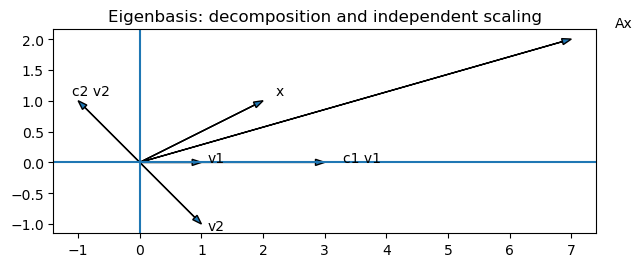

In [3]:
#This plot shows how a vector is decomposed along eigenvectors the transformation scales each component independently

import numpy as np
import matplotlib.pyplot as plt

# Define matrix
A = np.array([[3., 1.],
              [0., 2.]])

# Eigenvectors (manually chosen for clarity)
v1 = np.array([1., 0.])
v2 = np.array([1., -1.])

# Example vector
x = np.array([2., 1.])

# Decompose x in eigenbasis
P = np.column_stack([v1, v2])
Pinv = np.linalg.inv(P)
coords = Pinv @ x

# Components along eigenvectors
c1 = coords[0] * v1
c2 = coords[1] * v2

# Transformed vector
Ax = A @ x

def draw(ax, vec, label):
    ax.arrow(0, 0, vec[0], vec[1],
             head_width=0.1, length_includes_head=True)
    ax.text(vec[0]*1.1, vec[1]*1.1, label)

fig, ax = plt.subplots(figsize=(7,7))

# Draw eigenvectors
draw(ax, v1, "v1")
draw(ax, v2, "v2")

# Draw decomposition
draw(ax, c1, "c1 v1")
draw(ax, c2, "c2 v2")

# Draw original and transformed
draw(ax, x, "x")
draw(ax, Ax, "Ax")

ax.axhline(0)
ax.axvline(0)
ax.set_aspect('equal')
ax.set_title("Eigenbasis: decomposition and independent scaling")
plt.show()


💡 This plot shows that:

- $x$ is represented in the eigenvector basis:
  $$
  x = c_1v_1 + c_2v_2
  $$
- the transformation scales each eigenbasis coordinate independently:
  $$
  Ax = \lambda_1 c_1 v_1 + \lambda_2 c_2 v_2
  $$

👉 This is exactly what “no mixing of coordinates” means in practice. If a matrix has enough eigenvectors to form a basis, then we can choose coordinates where the transformation becomes simple independent scaling along each direction.

# 3. Formal proof of diagonalization

Define

$$P = [v_1 \; v_2 \; \cdots \; v_n]$$

and

$$D = \mathrm{diag}(\lambda_1,\dots,\lambda_n).$$

Then

$$
AP = A[v_1 \; v_2 \; \cdots \; v_n]
= [Av_1 \; Av_2 \; \cdots \; Av_n]
= [\lambda_1v_1 \; \lambda_2v_2 \; \cdots \; \lambda_nv_n].
$$

But multiplying $P$ by the diagonal matrix $D$ gives exactly the same scaling of columns:

$$
PD = [\lambda_1v_1 \; \lambda_2v_2 \; \cdots \; \lambda_nv_n].
$$

Hence

$$
AP = PD.
$$

If the eigenvectors are linearly independent, then $P$ is invertible, and therefore

$$
A = PDP^{-1}.
$$

## Interpretation

- $P^{-1}$: move from the standard basis to the eigenbasis
- $D$: scale independently along eigenvector directions
- $P$: return to the standard basis


A matrix is diagonalizable if and only if it has a full set of linearly independent eigenvectors, in which case it can be written as $A = PDP^{-1}$
, where $D$ contains the eigenvalues.

# 4. Why does $P^{-1}x$ give coordinates in the eigenbasis?

If

$$
P = [v_1 \; v_2 \; \cdots \; v_n],
$$

then for any coefficient vector

$$
c = \begin{bmatrix}c_1\\ \vdots \\ c_n\end{bmatrix},
$$

we have

$$
Pc = c_1v_1 + \cdots + c_nv_n.
$$

So $P$ maps **coordinates in the eigenbasis** to the actual vector in the standard basis.

If $x$ is given in the standard basis and we want its coordinates $c$ in the eigenbasis, solve

$$
Pc = x.
$$

Thus

$$
c = P^{-1}x.
$$

That is why $P^{-1}x$ is the coordinate vector of $x$ in the eigenvector basis.


# 5. Worked example: diagonalization by hand

Consider

$$
A = \begin{bmatrix}
3 & 1\\
0 & 2
\end{bmatrix}.
$$

We will compute:

- eigenvalues
- eigenvectors
- the decomposition $A = PDP^{-1}$
- a coordinate-level interpretation


In [4]:
A = np.array([[3.,1.],[0.,2.]])
A


array([[3., 1.],
       [0., 2.]])

## Step 1: eigenvalues

The characteristic polynomial is

$$
\det(A-\lambda I)
=
\det\begin{bmatrix}
3-\lambda & 1\\
0 & 2-\lambda
\end{bmatrix}
=
(3-\lambda)(2-\lambda).
$$

Therefore the eigenvalues are

$$\lambda_1 = 3,\qquad \lambda_2 = 2.$$


## Step 2: eigenvectors

For $\lambda_1 = 3$,

$$
(A-3I)v = 0
\Rightarrow
\begin{bmatrix}
0 & 1\\
0 & -1
\end{bmatrix}
\begin{bmatrix}
x\\y
\end{bmatrix}
=0
\Rightarrow y=0.
$$

So one eigenvector is

$$
v_1 = \begin{bmatrix}1\\0\end{bmatrix}.
$$

For $\lambda_2 = 2$,

$$
(A-2I)v = 0
\Rightarrow
\begin{bmatrix}
1 & 1\\
0 & 0
\end{bmatrix}
\begin{bmatrix}
x\\y
\end{bmatrix}
=0
\Rightarrow x+y=0.
$$

So one eigenvector is

$$
v_2 = \begin{bmatrix}1\\-1\end{bmatrix}.
$$


In [5]:
v1 = np.array([1.,0.])
v2 = np.array([1.,-1.])
P = np.column_stack([v1, v2])
D = np.diag([3., 2.])
Pinv = np.linalg.inv(P)

P, D, Pinv


(array([[ 1.,  1.],
        [ 0., -1.]]),
 array([[3., 0.],
        [0., 2.]]),
 array([[ 1.,  1.],
        [-0., -1.]]))

In [6]:
A_reconstructed = P @ D @ Pinv
A_reconstructed, np.allclose(A, A_reconstructed)


(array([[3., 1.],
        [0., 2.]]),
 True)

So indeed,

$
A = PDP^{-1}.
$

This means the transformation can be understood as:

1. convert to the eigenbasis
2. scale the first coordinate by \(3\)
3. scale the second coordinate by \(2\)
4. convert back


## Coordinate demonstration

Take

$$
x = \begin{bmatrix}2\\1\end{bmatrix}.
$$

Then

$$
c = P^{-1}x
$$

gives the coordinates of $x$ in the eigenbasis.


In [7]:
x = np.array([2.,1.])
coords = Pinv @ x
Ax = A @ x
coords_after = Pinv @ Ax
coords, Ax, coords_after


(array([ 3., -1.]), array([7., 2.]), array([ 9., -2.]))

In [8]:
D @ coords


array([ 9., -2.])

The last two vectors match, confirming that in eigen-coordinates the transformation is just diagonal scaling.


# 6. Visualization: standard basis vs eigenbasis


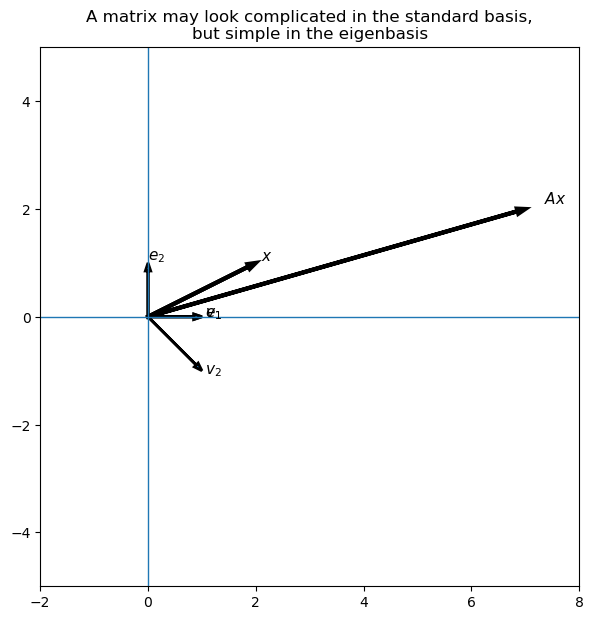

In [9]:
def draw_arrow(ax, vec, label, origin=(0,0), **kwargs):
    ax.arrow(origin[0], origin[1], vec[0], vec[1],
             head_width=0.10, length_includes_head=True, **kwargs)
    ax.text(origin[0] + 1.05*vec[0], origin[1] + 1.05*vec[1], label, fontsize=11)

fig, ax = plt.subplots(figsize=(7,7))
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

e1 = np.array([1.,0.]); e2 = np.array([0.,1.])
draw_arrow(ax, e1, r"$e_1$", linewidth=2)
draw_arrow(ax, e2, r"$e_2$", linewidth=2)
draw_arrow(ax, v1, r"$v_1$", linewidth=2)
draw_arrow(ax, v2, r"$v_2$", linewidth=2)
draw_arrow(ax, x, r"$x$", linewidth=3)
draw_arrow(ax, Ax, r"$Ax$", linewidth=3)

ax.set_xlim(-2,8)
ax.set_ylim(-5,5)
ax.set_aspect('equal')
ax.set_title("A matrix may look complicated in the standard basis,\nbut simple in the eigenbasis")
plt.show()


# Application: Dynamics and Stability of Repeated Transformations

One of the most important applications of diagonalization is understanding what happens when a transformation is applied repeatedly.

This appears in:

- iterative algorithms
- dynamical systems
- optimization
- neural network training dynamics

---

## The Problem

Suppose we repeatedly apply a matrix $A$ to a vector $x$:

$$x_k = A^k x_0$$

What happens as $k \to \infty$?

Does the system:
- explode?
- vanish?
- stabilize?

---

## The Key Idea

If $A$ is diagonalizable:

$$
A = P D P^{-1}
$$

then:

$$
A^k = P D^k P^{-1}
$$

and therefore:

$$
x_k = A^k x_0 = P D^k P^{-1} x_0
$$

---

## Why This Is Powerful

In the eigenbasis:

$$
x_0 = c_1 v_1 + c_2 v_2 + \cdots + c_n v_n
$$

then:

$$
x_k = c_1 \lambda_1^k v_1 + \cdots + c_n \lambda_n^k v_n
$$

---

## Key Insight

Each component evolves independently:

- if $|\lambda_i| > 1$ → grows (unstable)
- if $|\lambda_i| < 1$ → decays (stable)
- if $|\lambda_i| = 1$→ persists (neutral)

So the long-term behavior is completely determined by eigenvalues.

---

## Interpretation

> The dominant eigenvalue controls the long-term direction of the system.

Eventually, the vector aligns with the eigenvector corresponding to the largest $|\lambda|$.

---

## Visualization

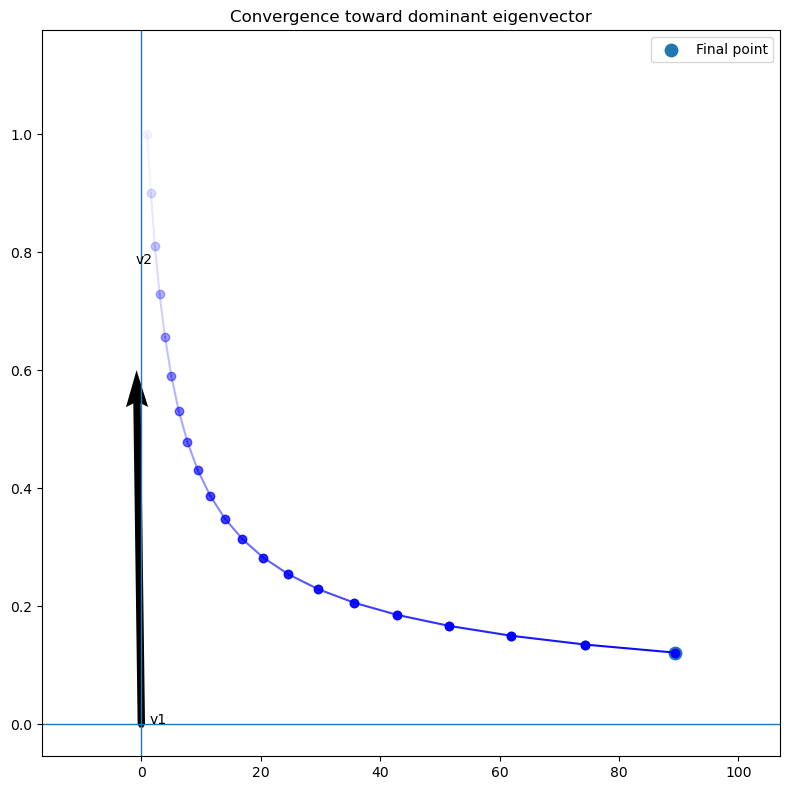

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Define matrix
A = np.array([[1.2, 0.4],
              [0.0, 0.9]])

# Initial vector
x = np.array([1.0, 1.0])

trajectory = [x]

# Iterate
for _ in range(20):
    x = A @ x
    trajectory.append(x)

trajectory = np.array(trajectory)

# Eigenvectors
eigvals, eigvecs = np.linalg.eig(A)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8, 8))

# Plot trajectory with fading effect
for i in range(len(trajectory) - 1):
    alpha = (i + 1) / len(trajectory)
    ax.plot(trajectory[i:i+2, 0],
            trajectory[i:i+2, 1],
            marker='o',
            alpha=alpha,
            color='blue')

# Highlight final point
ax.scatter(trajectory[-1, 0], trajectory[-1, 1],
           s=80, label="Final point")

# Eigenvectors (normalized for visibility)
for i in range(2):
    v = eigvecs[:, i]
    v = v / np.linalg.norm(v)

    ax.quiver(0, 0, v[0], v[1],
              angles='xy', scale_units='xy', scale=1,
              width=0.01)

    ax.text(v[0]*1.3, v[1]*1.3, f"v{i+1}")

# Dynamic axis limits with padding
xmin, xmax = trajectory[:, 0].min(), trajectory[:, 0].max()
ymin, ymax = trajectory[:, 1].min(), trajectory[:, 1].max()

pad_x = (xmax - xmin) * 0.2
pad_y = (ymax - ymin) * 0.2

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

# Axes
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_aspect('auto')
ax.set_title("Convergence toward dominant eigenvector")
ax.legend()

plt.tight_layout()
plt.show()

# Application: PCA — Finding Structure in Data (Not Diagonalizing A)

Principal Component Analysis (PCA) is one of the most important applications of eigenvalues and eigenvectors in machine learning.

However, it is important to clarify:

> PCA is **not** about diagonalizing a transformation matrix $A$.  
> PCA is about finding directions in the data where **variance is maximized**.

---

## The Real Question PCA Asks

Given a dataset $X \in \mathbb{R}^{n \times d}$ (rows = samples, columns = features),

PCA asks:

> **Along which direction $v$ does the data vary the most?**

This is fundamentally an **optimization problem**, not a transformation problem.

---

## The Objective (Core Idea)

We want to find a unit vector $v$ that maximizes:

$\text{Var}(Xv)$

Assuming the data is centered:

$\text{Var}(Xv) = \frac{1}{n} \|Xv\|^2$

Rewriting:

$= \frac{1}{n} v^T X^T X v$

Define the covariance matrix:

$C = \frac{1}{n} X^T X$

So the problem becomes:

$\max_{\|v\|=1} v^T C v$

---

## Geometric Interpretation of the Objective

The quantity $v^T C v$ measures:

> how much the data spreads along direction $v$

Geometrically:

- project all data points onto direction $v$
- measure how spread out those projections are
- choose the direction where this spread is maximized

---

## Why Does This Lead to Eigenvectors?

This is the key geometric insight.

### Step 1 — Think of $C$ as a transformation

The covariance matrix $C$ is symmetric, so it:

- stretches space along orthogonal directions  
- those directions are its eigenvectors  

---

### Step 2 — Unit sphere becomes an ellipse

If you take all unit vectors $v$ (a sphere) and apply $C$, you get:

> an **ellipsoid**

- axes of the ellipsoid = eigenvectors  
- lengths of axes = eigenvalues  

---

### Step 3 — Maximization becomes geometric

Now consider:

$v^T C v$

This is:

- the squared length of $Cv$ projected back onto $v$
- or equivalently: how much $v$ aligns with its stretched version

---

### Step 4 — Where is this maximized?

The maximum happens when:

> $v$ points in the direction where $C$ stretches the most

That direction is:

👉 the eigenvector with the largest eigenvalue

---

### Intuition in One Sentence

> The direction of maximum variance is the direction that gets stretched the most by the covariance matrix—and those directions are exactly the eigenvectors.

---

## Why Eigenvectors Appear (Formal Result)

The optimization:

$\max_{\|v\|=1} v^T C v$

has solution:

- $v$ = eigenvector of $C$  
- maximum value = largest eigenvalue  

---

## Mathematical Procedure

1. Center the data:  
   $X \leftarrow X - \text{mean}(X)$  

2. Compute covariance:  
   $C = \frac{1}{n} X^T X$  

3. Compute eigenvalues and eigenvectors of $C$

---

## Interpretation

- eigenvectors of $C$ → principal directions  
- eigenvalues → variance along those directions  

---

## Important Distinction

- Diagonalization:  
  analyzes how a matrix $A$ transforms vectors  

- PCA:  
  analyzes how **data is distributed in space**

👉 We are not studying a transformation—we are extracting structure.

---

## Connection to SVD

Instead of computing $C = X^T X$, we can use:

$X = U \Sigma V^T$

Then:

- columns of $V$ = principal directions  
- $\Sigma^2 / n$ = eigenvalues  

---

## Key Insight

> PCA finds the coordinate system where the data has maximum variance along independent directions.

---

## One-Sentence Summary

> PCA turns “where is the data most spread out?” into maximizing $v^T C v$, whose solution naturally aligns with the eigenvectors of the covariance matrix.

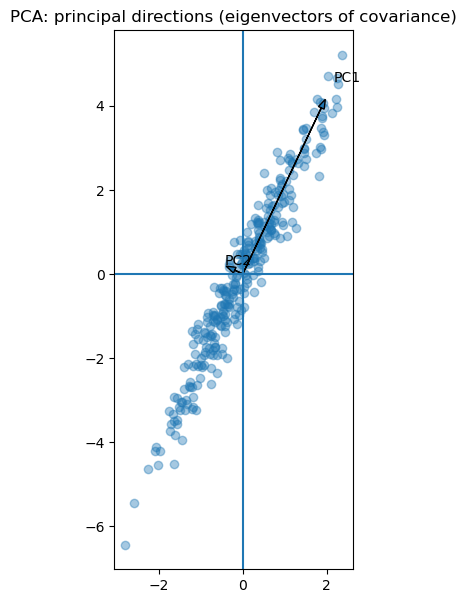

In [26]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Generate correlated data
n = 300
x = np.random.randn(n)
y = 2*x + 0.5*np.random.randn(n)

X = np.vstack([x, y]).T

# Center data
X = X - X.mean(axis=0)

# Covariance
C = np.cov(X.T)

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(C)

# Sort descending
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

# Plot
fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(X[:,0], X[:,1], alpha=0.4)

# Draw principal components
for i in range(2):
    vec = 2*np.sqrt(eigvals[i]) * eigvecs[:, i]
    ax.arrow(0,0, vec[0], vec[1], head_width=0.15, length_includes_head=True)
    ax.text(vec[0]*1.1, vec[1]*1.1, f"PC{i+1}")

ax.axhline(0)
ax.axvline(0)
ax.set_aspect('equal')
ax.set_title("PCA: principal directions (eigenvectors of covariance)")
plt.show()

## What This Plot Shows

- data lies mostly along one direction  
- PCA finds that direction automatically  
- the first eigenvector captures most variance  

---

## Why This Matters in ML

- dimensionality reduction  
- preprocessing before training  
- noise filtering  
- feature extraction  

---

## One-Sentence Takeaway

> PCA uses eigenvectors to find the directions where the data contains the most information.

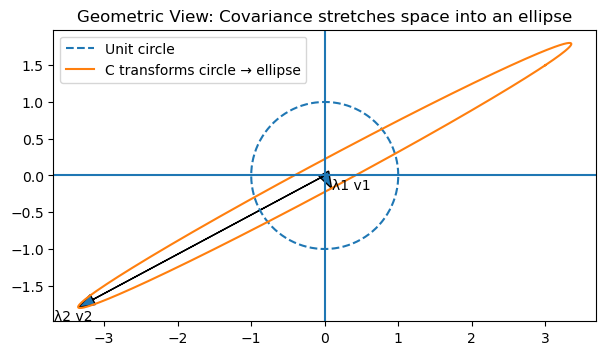

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Create a covariance-like symmetric matrix
C = np.array([[3.0, 1.5],
              [1.5, 1.0]])

# Generate unit circle
theta = np.linspace(0, 2*np.pi, 400)
circle = np.vstack([np.cos(theta), np.sin(theta)])

# Transform circle using C
ellipse = C @ circle

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(C)

# Plot
fig, ax = plt.subplots(figsize=(7,7))

# Original unit circle
ax.plot(circle[0], circle[1], linestyle='--', label="Unit circle")

# Transformed ellipse
ax.plot(ellipse[0], ellipse[1], label="C transforms circle → ellipse")

# Plot eigenvectors scaled by eigenvalues
for i in range(2):
    v = eigvecs[:, i]
    scaled_v = eigvals[i] * v
    ax.arrow(0, 0, scaled_v[0], scaled_v[1],
             head_width=0.15, length_includes_head=True)
    ax.text(scaled_v[0]*1.1, scaled_v[1]*1.1, f"λ{i+1} v{i+1}")

# Axes
ax.axhline(0)
ax.axvline(0)
ax.set_aspect('equal')

ax.set_title("Geometric View: Covariance stretches space into an ellipse")
ax.legend()

plt.show()

# 7. When diagonalization fails

Not every matrix has enough independent eigenvectors.

Example:

$$
J = \begin{bmatrix}
1 & 1\\
0 & 1
\end{bmatrix}.
$$

This matrix has only one eigenvalue, $\lambda=1$, and does not have two linearly independent eigenvectors.

Therefore it cannot be diagonalized, even though it is square.


In [10]:
J = np.array([[1.,1.],[0.,1.]])
eigvals_J, eigvecs_J = np.linalg.eig(J)
eigvals_J, eigvecs_J


(array([1., 1.]),
 array([[ 1., -1.],
        [ 0.,  0.]]))

# Orthogonality vs Basis — Why It Matters

A common source of confusion is the role of orthogonality when working with bases and eigenvectors.

---

## What is a Basis?

A set of vectors forms a basis if:

- they are **linearly independent**
- they **span the space**

That’s all.

> Orthogonality is NOT required.

---

## Example 1 — Valid Basis (Non-Orthogonal)

Consider:

$v_1 = \begin{bmatrix}1 \\ 0\end{bmatrix}, \quad
v_2 = \begin{bmatrix}1 \\ 1\end{bmatrix}$

These vectors:

- are not perpendicular  
- but are linearly independent  

So they form a valid basis.

---

## Example 2 — Orthonormal Basis

Standard basis:

$e_1 = \begin{bmatrix}1 \\ 0\end{bmatrix}, \quad
e_2 = \begin{bmatrix}0 \\ 1\end{bmatrix}$

These vectors are:

- perpendicular (orthogonal)  
- unit length  

👉 This is an **orthonormal basis**

---

## Key Difference

### In an orthonormal basis:
- coordinates are easy to compute  
- each component is independent  
- coefficients are just dot products  

### In a non-orthogonal basis:
- coordinates are coupled  
- coefficients interact  
- must solve a system of equations  

---

## Why Non-Orthogonal Coordinates Are Messy

If:

$x = c_1 v_1 + c_2 v_2$

then in general:

$c_1 \neq x \cdot v_1$

because $v_1$ and $v_2$ are not perpendicular.

👉 projecting onto one direction mixes in the other.

---

## Matrix View

Let:

$P = [v_1 \; v_2]$

Then:

$x = P c \quad \Rightarrow \quad c = P^{-1} x$

👉 coordinates require solving a system

---

## Orthogonal Case (Special)

If the basis is orthonormal:

$c = P^T x$

👉 no inversion needed  
👉 computation is stable and simple  

---

## Why This Matters in Practice

### 1. PCA
- uses orthogonal directions  
- ensures independent variance components  

### 2. SVD
- produces orthonormal bases  
- avoids coordinate coupling  

### 3. Numerical Stability
- orthogonal bases reduce errors  

---

## Key Insight

> Orthogonality is not required for a basis, but it removes interaction between coordinates and makes analysis much simpler.

---

## One-Sentence Summary

> A basis only needs independence, but orthogonality makes coordinates decoupled, interpretable, and computationally efficient.

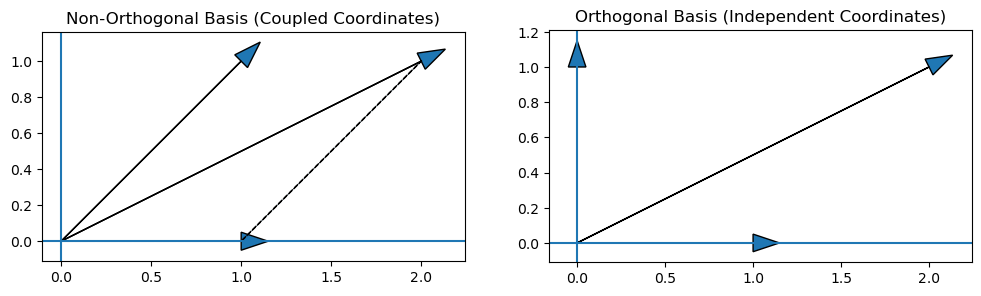

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Non-orthogonal basis
v1 = np.array([1, 0])
v2 = np.array([1, 1])

# Orthogonal basis
u1 = np.array([1, 0])
u2 = np.array([0, 1])

# Vector
x = np.array([2, 1])

# Decompose in non-orthogonal basis
P = np.column_stack([v1, v2])
c = np.linalg.inv(P) @ x
c1, c2 = c[0]*v1, c[1]*v2

fig, axs = plt.subplots(1, 2, figsize=(12,6))

# Non-orthogonal plot
axs[0].arrow(0,0,v1[0],v1[1], head_width=0.1)
axs[0].arrow(0,0,v2[0],v2[1], head_width=0.1)
axs[0].arrow(0,0,x[0],x[1], head_width=0.1)
axs[0].arrow(0,0,c1[0],c1[1], linestyle='--')
axs[0].arrow(c1[0],c1[1],c2[0],c2[1], linestyle='--')
axs[0].set_title("Non-Orthogonal Basis (Coupled Coordinates)")
axs[0].axhline(0)
axs[0].axvline(0)
axs[0].set_aspect('equal')

# Orthogonal plot
axs[1].arrow(0,0,u1[0],u1[1], head_width=0.1)
axs[1].arrow(0,0,u2[0],u2[1], head_width=0.1)
axs[1].arrow(0,0,x[0],x[1], head_width=0.1)
axs[1].set_title("Orthogonal Basis (Independent Coordinates)")
axs[1].axhline(0)
axs[1].axvline(0)
axs[1].set_aspect('equal')

plt.show()

# Why PCA Diagonalizes the Covariance Matrix

We have seen that:

- PCA finds directions of maximum variance  
- those directions are eigenvectors of the covariance matrix  

Now the key question:

> Why does PCA *diagonalize* the covariance matrix?

---

## Step 1 — What covariance represents

Given centered data $X$:

$C = \frac{1}{n} X^T X$

The covariance matrix tells us:

- diagonal entries → variance of each feature  
- off-diagonal entries → correlation between features  

👉 Off-diagonal terms = **coupling between dimensions**

---

## Step 2 — The problem with the original coordinates

In the original basis:

- features are correlated  
- covariance matrix is NOT diagonal  

Example:

$C = \begin{bmatrix}
2 & 1 \\
1 & 2
\end{bmatrix}$

👉 the $1$'s indicate that the two directions are not independent  

---

## Step 3 — What PCA does

PCA finds a new basis:

$P = [v_1 \; v_2 \; \cdots \; v_d]$

where $v_i$ are eigenvectors of $C$

Now we transform the data:

$Z = X P$

---

## Step 4 — Covariance in the new basis

The covariance of transformed data:

$C' = \frac{1}{n} Z^T Z$

Substitute $Z = XP$:

$C' = \frac{1}{n} P^T X^T X P$

So:

$C' = P^T C P$

---

## Step 5 — Why this becomes diagonal

Since $P$ contains eigenvectors of $C$:

$C P = P D$

where $D$ is diagonal (eigenvalues)

So:

$C' = P^T C P = P^T (P D) = D$

---

## 🎯 Final Result

> In the PCA basis, the covariance matrix becomes diagonal.

---

## Geometric Meaning

This is the most important insight:

- original coordinates → correlated directions  
- PCA coordinates → independent directions  

👉 PCA rotates the space so that:

- each axis captures independent variation  
- no interaction between axes remains  

---

## Connection to Orthogonality

Because $C$ is symmetric:

- eigenvectors are orthogonal  
- $P^T = P^{-1}$  

So the transformation is a **pure rotation (or reflection)**

👉 No distortion—only reorientation

---

## Why This Matters

After PCA:

- covariance matrix is diagonal  
- components are uncorrelated  
- each dimension has independent meaning  

This is why PCA is so powerful for:

- dimensionality reduction  
- feature extraction  
- noise removal  

---

## 🔥 Deep Insight

> PCA is not just finding directions—it is removing dependence between dimensions.

---

## One-Sentence Summary

> PCA finds an orthogonal basis in which the covariance matrix becomes diagonal, meaning all directions become statistically independent (uncorrelated).

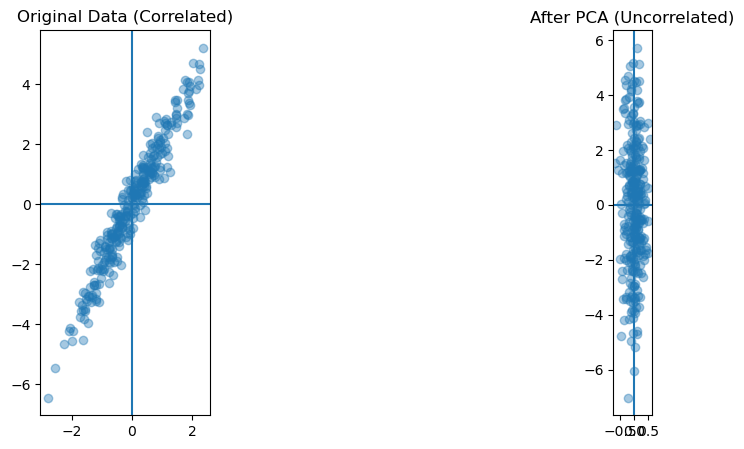

In [31]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Generate correlated data
n = 300
x = np.random.randn(n)
y = 2*x + 0.5*np.random.randn(n)

X = np.vstack([x, y]).T
X = X - X.mean(axis=0)

# PCA
C = np.cov(X.T)
eigvals, eigvecs = np.linalg.eigh(C)

# Transform data
Z = X @ eigvecs

fig, axs = plt.subplots(1,2, figsize=(12,5))

# Original data
axs[0].scatter(X[:,0], X[:,1], alpha=0.4)
axs[0].set_title("Original Data (Correlated)")

# Transformed data
axs[1].scatter(Z[:,0], Z[:,1], alpha=0.4)
axs[1].set_title("After PCA (Uncorrelated)")

for ax in axs:
    ax.axhline(0)
    ax.axvline(0)
    ax.set_aspect('equal')

plt.show()

# Singular Value Decomposition (SVD): The Universal Version of PCA

We have seen that PCA diagonalizes the covariance matrix:

$C = \frac{1}{n} X^T X$

by finding an orthogonal basis where:

$C' = P^T C P = D$

This removes **correlation (coupling) between features**.

Now we ask a deeper question:

> Can we do something similar for **any matrix**, not just covariance?

The answer is:

👉 **Yes — this is exactly what SVD does.**

---

## The SVD Decomposition

For any matrix $A \in \mathbb{R}^{m \times n}$:

$A = U \Sigma V^T$

where:

- $U$ has orthonormal columns  
- $V$ has orthonormal columns  
- $\Sigma$ is diagonal with nonnegative entries $\sigma_1 \ge \sigma_2 \ge \cdots \ge 0$  

These $\sigma_i$ are the **singular values**.

---

## Geometric Interpretation

SVD decomposes a transformation into three steps:

1. $V^T$ → rotate (change input coordinates)  
2. $\Sigma$ → scale along orthogonal directions  
3. $U$ → rotate again (to output space)  

So:

> Any linear transformation = rotation + independent scaling + rotation

---

## Connection to PCA

Recall PCA:

- works with $C = X^T X$
- diagonalizes covariance
- finds directions of maximum variance

Now apply SVD to the data matrix:

$X = U \Sigma V^T$

Then:

$X^T X = V \Sigma^2 V^T$

---

## 🔑 Key Result

- columns of $V$ = eigenvectors of covariance  
- $\Sigma^2 / n$ = eigenvalues  

👉 So:

> PCA is just SVD applied to the data matrix.

---

## What SVD Really Does (Deep Insight)

SVD generalizes the idea of PCA:

- PCA removes **correlation in data**
- SVD removes **interaction in transformations**

---

## Geometric View (Unifying Idea)

Think of applying $A$ to all unit vectors:

- a unit sphere becomes an **ellipsoid**

SVD tells us:

- directions of ellipsoid axes = columns of $V$  
- lengths of axes = singular values  
- output orientation = columns of $U$

---

## Why This Matters

In the original coordinates:

- transformation mixes directions  
- components interact (coupled)

In SVD coordinates:

- everything becomes independent  
- no mixing between components  

👉 transformation becomes diagonal in the right basis

---

## Relation to Diagonalization

Diagonalization (if possible):

$A = P D P^{-1}$

- works only if enough eigenvectors exist  
- may use non-orthogonal basis  

SVD:

$A = U \Sigma V^T$

- always exists  
- uses orthogonal bases  
- works even for non-square matrices  

---

## 🔥 The Unifying Principle

All these methods are solving the same problem:

> Find a coordinate system where the transformation or data becomes simple and decoupled.

- Diagonalization → decouples transformation (when possible)  
- PCA → decouples variance (covariance becomes diagonal)  
- SVD → decouples *any* linear map  

---

## One-Sentence Summary

> SVD is the most general way to transform a matrix into a form where it acts as independent scaling along orthogonal directions—extending the idea of PCA and diagonalization to all matrices.

# Application: Low-Rank Approximation (Model Compression)

Modern machine learning models use very large matrices.

SVD allows us to approximate them with much smaller ones.

---

## The Problem

Given a large matrix $A$, we want:

- fewer parameters  
- faster computation  
- minimal loss of information  

---

## The Key Idea

Using SVD:

$A = U \Sigma V^T$

We approximate using only top $k$ components:

$A_k = U_k \Sigma_k V_k^T$

---

## Key Insight

> Most of the important information is captured by the largest singular values.

So we can discard the small ones.

---

## Why This Works

- large singular values = important structure  
- small singular values = noise or redundancy  

---

## Visualization

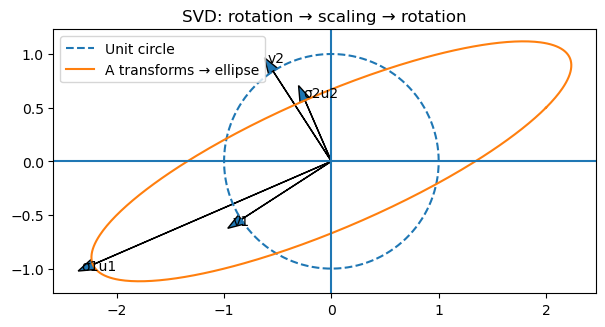

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Define a transformation
A = np.array([[2, 1],
              [0.5, 1]])

# Unit circle
theta = np.linspace(0, 2*np.pi, 400)
circle = np.vstack([np.cos(theta), np.sin(theta)])

# Transform
ellipse = A @ circle

# SVD
U, s, VT = np.linalg.svd(A)

fig, ax = plt.subplots(figsize=(7,7))

# Circle and ellipse
ax.plot(circle[0], circle[1], linestyle='--', label="Unit circle")
ax.plot(ellipse[0], ellipse[1], label="A transforms → ellipse")

# Singular vectors
for i in range(2):
    v = VT.T[:, i]
    u = U[:, i]
    
    ax.arrow(0,0,v[0],v[1], head_width=0.1)
    ax.text(v[0]*1.1,v[1]*1.1,f"v{i+1}")
    
    ax.arrow(0,0,s[i]*u[0],s[i]*u[1], head_width=0.1)
    ax.text(s[i]*u[0]*1.05,s[i]*u[1]*1.05,f"σ{i+1}u{i+1}")

ax.axhline(0)
ax.axvline(0)
ax.set_aspect('equal')
ax.set_title("SVD: rotation → scaling → rotation")
ax.legend()

plt.show()

# Why SVD Always Exists (Even When Diagonalization Fails)

We have seen that diagonalization requires:

- enough eigenvectors  
- matrix must be diagonalizable  

But many matrices are **not diagonalizable**.

So the key question:

> Why does SVD always exist for *any* matrix?

---

## Step 1 — The Trick: Look at $A^T A$

Given any matrix $A \in \mathbb{R}^{m \times n}$, consider:

$A^T A$

This matrix has very special properties:

- it is **symmetric**: $(A^T A)^T = A^T A$  
- it is **positive semi-definite**:  
  $v^T A^T A v = \|Av\|^2 \ge 0$

---

## Step 2 — Why This Is Important

Because $A^T A$ is symmetric:

👉 it always has:

- orthogonal eigenvectors  
- real eigenvalues  

So we can write:

$A^T A = V \Lambda V^T$

where:

- $V$ is orthogonal  
- $\Lambda$ is diagonal with nonnegative entries  

---

## Step 3 — Define Singular Values

Let:

$\sigma_i = \sqrt{\lambda_i}$

Then:

$\Lambda = \Sigma^2$

So:

$A^T A = V \Sigma^2 V^T$

---

## Step 4 — Construct the Decomposition

Now define:

$U = A V \Sigma^{-1}$

Then we get:

$A = U \Sigma V^T$

---

## 🎯 Key Insight

Even if $A$ itself is messy:

- $A^T A$ is always nice  
- we can always diagonalize it  
- this gives us $V$ and $\Sigma$  
- and from that we build $U$

---

## Geometric Interpretation

Think of $A$ acting on the unit sphere:

- input sphere → transformed into an ellipsoid  

SVD finds:

- directions of input axes → $V$  
- lengths of axes → $\Sigma$  
- output directions → $U$

---

## Why Diagonalization Can Fail

Diagonalization requires:

$A v = \lambda v$

This means:

> the direction must stay the same

But many transformations:

- rotate  
- shear  
- mix directions  

👉 so no such directions exist

---

## Why SVD Still Works

SVD relaxes the requirement:

Instead of:

> same direction before and after

it asks:

> can we find input directions that map to output directions with simple scaling?

Answer:

👉 always yes

---

## Deep Geometric Insight

- diagonalization → same direction scaling  
- SVD → input direction maps to output direction  

So:

> SVD allows different input/output directions, which is why it always exists

---

## 🔥 The Real Reason

> SVD works because it studies $A^T A$, which is always symmetric and therefore always diagonalizable.

---

## Connection to PCA

Recall:

$X^T X = V \Sigma^2 V^T$

👉 PCA is just the eigen-decomposition of $A^T A$

So:

- PCA = part of SVD  
- SVD = generalization of PCA  

---

## Final Intuition

- diagonalization fails because directions must stay fixed  
- SVD succeeds because it allows directions to change  

---

## One-Sentence Summary

> SVD always exists because it reduces the problem to diagonalizing the symmetric matrix $A^T A$, whose eigenvectors define the fundamental directions of the transformation.

## Mini-Project: PCA, SVD, and Image Compression

This notebook connects the theory of eigenvectors, covariance, PCA, and SVD through runnable mini-projects.

## Projects

1. PCA on correlated data  
2. Covariance ellipse visualization  
3. PCA via SVD  
4. SVD image compression  
5. Deep learning connection: low-rank structure

### Part 1 — Generate Correlated Data

PCA is about finding directions where data varies the most.

We generate a 2D dataset whose features are correlated, then center it.


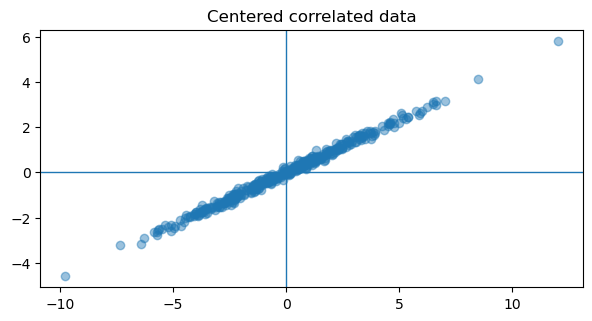

In [33]:
np.random.seed(42)

n = 400
z = np.random.randn(n)
noise = 0.35 * np.random.randn(n)

x1 = 3*z + noise
x2 = 1.4*z + 0.8*noise

X = np.column_stack([x1, x2])
X = X - X.mean(axis=0)

fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(X[:,0], X[:,1], alpha=0.45)
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.set_aspect("equal")
ax.set_title("Centered correlated data")
plt.show()


# Part 2 — Covariance Matrix

PCA does not directly ask what $X$ does as a transformation.

It asks:

> Along which direction does the data vary the most?

For centered data, the covariance matrix is:

$C = \frac{1}{n-1}X^T X$

The covariance matrix describes the shape of the data cloud:

- diagonal entries = variances
- off-diagonal entries = correlations


In [ ]:
C = np.cov(X.T)
print(C)


# Part 3 — PCA via Eigendecomposition

Because $C$ is symmetric, its eigenvectors are orthogonal.

In PCA:

- eigenvectors of $C$ = principal directions
- eigenvalues of $C$ = variance along those directions


In [ ]:
eigvals, eigvecs = np.linalg.eigh(C)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

print("Eigenvalues:")
print(eigvals)
print("\nEigenvectors:")
print(eigvecs)


In [ ]:
fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(X[:,0], X[:,1], alpha=0.35)

for i in range(2):
    vec = 2.5 * np.sqrt(eigvals[i]) * eigvecs[:, i]
    ax.arrow(0, 0, vec[0], vec[1], head_width=0.15, length_includes_head=True)
    ax.text(vec[0]*1.08, vec[1]*1.08, f"PC{i+1}", fontsize=12)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.set_aspect("equal")
ax.set_title("PCA directions are covariance eigenvectors")
plt.show()


# Part 4 — PCA Diagonalizes Covariance

Let $P$ contain the eigenvectors of $C$.

Transform the data:

$Z = XP$

Then the new covariance is:

$C' = P^T C P = D$

So PCA changes coordinates so the covariance becomes diagonal.

This means the new coordinates are uncorrelated.


In [ ]:
P = eigvecs
Z = X @ P
C_new = np.cov(Z.T)

print("Covariance before PCA:")
print(C)
print("\nCovariance after PCA:")
print(C_new)


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13,5))

axs[0].scatter(X[:,0], X[:,1], alpha=0.35)
axs[0].set_title("Original coordinates: correlated")

axs[1].scatter(Z[:,0], Z[:,1], alpha=0.35)
axs[1].set_title("PCA coordinates: diagonal covariance")

for ax in axs:
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_aspect("equal")

plt.show()


# Part 5 — Unit Circle to Covariance Ellipse

The covariance matrix transforms the unit circle into an ellipse.

- ellipse axes = eigenvectors
- axis lengths = eigenvalues

The longest axis gives the first principal component.


In [ ]:
theta = np.linspace(0, 2*np.pi, 500)
circle = np.vstack([np.cos(theta), np.sin(theta)])
ellipse = C @ circle

fig, ax = plt.subplots(figsize=(7,7))
ax.plot(circle[0], circle[1], linestyle="--", label="Unit circle")
ax.plot(ellipse[0], ellipse[1], label="Covariance ellipse")

for i in range(2):
    vec = eigvals[i] * eigvecs[:, i]
    ax.arrow(0, 0, vec[0], vec[1], head_width=0.15, length_includes_head=True)
    ax.text(vec[0]*1.08, vec[1]*1.08, f"λ{i+1}v{i+1}", fontsize=11)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.set_aspect("equal")
ax.set_title("Covariance geometry: circle becomes ellipse")
ax.legend()
plt.show()


# Part 6 — PCA via SVD

Instead of diagonalizing covariance directly, apply SVD to the centered data matrix:

$X = U\Sigma V^T$

Then:

$X^T X = V\Sigma^2V^T$

Therefore:

- columns of $V$ are principal directions
- $\Sigma^2/(n-1)$ are covariance eigenvalues

So PCA via covariance eigendecomposition and PCA via SVD are equivalent.


In [ ]:
U, s, VT = np.linalg.svd(X, full_matrices=False)
V = VT.T
eigvals_svd = s**2 / (n - 1)

print("Covariance eigenvalues:")
print(eigvals)
print("\nSVD-derived eigenvalues:")
print(eigvals_svd)

print("\nAbsolute alignment between eigenvectors and right singular vectors:")
print(np.abs(eigvecs.T @ V))


# Part 7 — SVD Image Compression

For any image matrix $A$:

$A = U\Sigma V^T$

A rank-$k$ approximation is:

$A_k = U_k\Sigma_kV_k^T$

Keeping only the top singular values compresses the matrix while preserving the most important structure.


In [ ]:
# Synthetic grayscale image generated offline
height, width = 160, 220
yy, xx = np.mgrid[-1:1:complex(height), -1:1:complex(width)]

image = (
    np.exp(-8*((xx+0.35)**2 + (yy+0.25)**2)) +
    0.8*np.exp(-14*((xx-0.35)**2 + (yy-0.2)**2)) +
    0.5*np.sin(8*xx)*np.cos(6*yy)
)

image = (image - image.min()) / (image.max() - image.min())

plt.figure(figsize=(7,5))
plt.imshow(image, cmap="gray")
plt.title("Original synthetic image")
plt.axis("off")
plt.show()


In [ ]:
U_img, s_img, VT_img = np.linalg.svd(image, full_matrices=False)

def reconstruct(k):
    return U_img[:, :k] @ np.diag(s_img[:k]) @ VT_img[:k, :]

ks = [1, 5, 10, 25, 50, 100]
fig, axs = plt.subplots(2, 3, figsize=(12,8))

for ax, k in zip(axs.ravel(), ks):
    ax.imshow(reconstruct(k), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Rank {k}")
    ax.axis("off")

plt.suptitle("SVD image compression")
plt.show()


# Part 8 — Reconstruction Error and Singular Values

As $k$ increases, reconstruction error decreases.

The singular value spectrum shows how much structure each singular direction contributes.


# Part 9 — Parameter Savings

Original image parameters:

$height \times width$

Rank-$k$ SVD parameters:

$height\cdot k + k + width\cdot k$

This can be much smaller when $k$ is small.


In [ ]:
original_params = height * width

for k in [5, 10, 25, 50]:
    compressed = height*k + k + width*k
    print(f"k={k:>3}: compressed params={compressed:>6}, ratio={compressed/original_params:.3f}")


# Deep Learning Connection

The same idea appears in neural networks.

Large weight matrices can sometimes be approximated as:

$W \approx U_k\Sigma_kV_k^T$

This can reduce:

- memory usage
- parameter count
- inference cost

Low-rank structure also appears in:

- embeddings
- attention matrices
- model compression
- efficient fine-tuning

---

# Final Unified Insight

PCA, diagonalization, and SVD all search for better coordinates.

- PCA diagonalizes covariance
- SVD decouples any matrix into orthogonal directions plus scaling
- low-rank approximation keeps the most important directions

> The right basis turns complicated structure into simple scaling.


# 18. Practical deep learning connections

## 18.1 Weight compression
Large dense layers can often be factorized as

\[
W \approx U_k\Sigma_kV_k^T
\]

to reduce inference cost.

## 18.2 Embedding analysis
Singular values of embedding matrices can reveal:

- redundancy
- anisotropy
- concentration of information in a few dominant directions

## 18.3 Training dynamics
The spectrum of the Hessian or Fisher-like matrices can reveal:

- stiffness
- sharp minima
- saddle structure
- ill-conditioning

## 18.4 Representation collapse
If many singular values shrink toward zero, learned representations may collapse into a low-dimensional subspace.

## 18.5 PCA as pretraining or exploratory analysis
Before training a model, PCA can expose:

- dominant feature directions
- noisy dimensions
- intrinsic dimensionality


# 19. Final conceptual summary

## Eigendecomposition
Use it when a square matrix has enough eigenvectors.  
It reveals directions that remain aligned with themselves under the map.

\[
A = PDP^{-1}
\]

## SVD
Use it for any matrix.  
It reveals orthogonal input directions, orthogonal output directions, and scaling in between.

\[
A = U\Sigma V^T
\]

## PCA
Use it to find directions of maximum variance in data.  
It can be computed either through covariance eigenvectors or through data-matrix SVD.

## Optimization
Eigenvalues of curvature matrices reveal how steep, flat, or unstable the loss landscape is.

### One sentence summary

> Much of machine learning becomes easier when you express transformations, data, or curvature in the right basis.


# SVD and Eigenvalues — The Hidden Structure

SVD is closely related to eigendecomposition, but in a more general way.

For any matrix $A$:

- the singular values $\sigma_i$ are the square roots of eigenvalues of:
  $A^T A$

- columns of $V$ are eigenvectors of $A^T A$
- columns of $U$ are eigenvectors of $A A^T$

---

## Key Insight

> SVD works by diagonalizing $A^T A$, which is always symmetric.

This is why:

- eigendecomposition may fail  
- SVD always succeeds  

---

## Why This Matters

- gives a stable way to analyze any matrix  
- connects geometry (SVD) to variance (PCA)  
- bridges linear algebra and statistics  

In [34]:
U, s, VT = np.linalg.svd(A)
Sigma = np.zeros_like(A)
Sigma[:len(s), :len(s)] = np.diag(s)

A_svd = U @ Sigma @ VT
print(np.allclose(A, A_svd))

True


## Interpretation

This confirms:

$A = U \Sigma V^T$

SVD is not an approximation — it is an exact decomposition.

Approximation only comes when we truncate singular values.

## Geometry of SVD (Refined View)

In [35]:
theta = np.linspace(0, 2*np.pi, 400)
circle = np.vstack([np.cos(theta), np.sin(theta)])
ellipse = A @ circle

## Geometric Interpretation (Refined)

- input unit circle → transformed into an ellipse  
- right singular vectors ($V$) → input directions  
- singular values → scaling factors  
- left singular vectors ($U$) → output directions  

---

## Key Insight

> SVD identifies the directions that are most stretched by the transformation.

This is the transformation analogue of PCA.

## Eigendecomposition vs SVD (Conceptual Positioning)

# Eigendecomposition vs SVD — When to Use What

| Feature | Eigendecomposition | SVD |
|---|---|---|
| Matrix type | square only | any matrix |
| Always exists? | no | yes |
| Directions | invariant directions | optimal input/output directions |
| Orthogonality | not guaranteed | guaranteed |
| Use case | theoretical analysis | practical ML |

---

## Key Insight

> Eigendecomposition studies when directions stay fixed  
> SVD studies how directions change in the best possible way

## Low-Rank Approximation (Core Practical Tool)

# Low-Rank Approximation — The Most Useful SVD Application

Given:

$A = U \Sigma V^T$

We approximate:

$A_k = U_k \Sigma_k V_k^T$

---

## Key Insight

> Most structure of a matrix is captured by the largest singular values.

This is the foundation of:

- compression  
- denoising  
- efficient modeling  

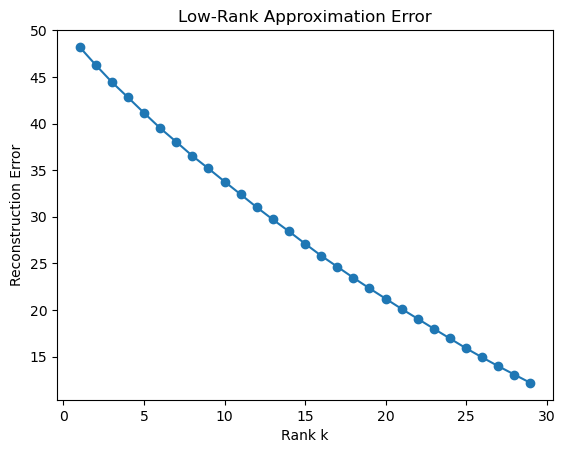

In [36]:
np.random.seed(1)
A = np.random.randn(50, 50)

U, s, VT = np.linalg.svd(A)

errors = []
ks = range(1, 30)

for k in ks:
    Ak = U[:, :k] @ np.diag(s[:k]) @ VT[:k, :]
    errors.append(np.linalg.norm(A - Ak, ord='fro'))

plt.plot(ks, errors, marker='o')
plt.xlabel("Rank k")
plt.ylabel("Reconstruction Error")
plt.title("Low-Rank Approximation Error")
plt.show()

## Interpretation

- small $k$ → large error  
- increasing $k$ → rapid improvement  
- later → diminishing returns  

👉 only a few directions carry most information

# PCA Revisited — Now Through SVD

Recall:

$X = U \Sigma V^T$

Then:

- columns of $V$ = principal directions  
- $\Sigma^2/(n-1)$ = variances  

---

## Key Insight

> PCA is SVD applied to the data matrix.

This avoids explicitly computing covariance and is more numerically stable.

# Optimization and Hessian — Eigenvalues in Deep Learning

The Hessian matrix $H$ describes curvature of the loss.

- eigenvectors → principal directions of curvature  
- eigenvalues → curvature magnitude  

---

## Interpretation

- large eigenvalues → steep directions  
- small eigenvalues → flat directions  
- negative eigenvalues → saddle points  

---

## Key Insight

> Optimization becomes easier when we understand curvature in the eigenbasis.

In [ ]:
H = np.array([[6., 2.],
              [2., 3.]])
eigvals_H, eigvecs_H = np.linalg.eigh(H)
print(eigvals_H)

# Deep Learning Connections

## 1. Model Compression
$W \approx U_k \Sigma_k V_k^T$

- reduces parameters  
- speeds up inference  

---

## 2. Embeddings
Singular values reveal:

- redundancy  
- intrinsic dimension  

---

## 3. Training Dynamics
Spectrum of Hessian shows:

- stiffness  
- stability  
- conditioning  

---

## 4. Representation Collapse
Small singular values → low-dimensional collapse  

---

## 5. PCA for Data Understanding
- detect noise  
- find structure  
- reduce dimension  

---

## Key Insight

> Spectral structure (eigenvalues & singular values) reveals how information is distributed.

# Final Conceptual Summary

## Eigendecomposition
$A = P D P^{-1}$  
→ works when directions stay fixed  

---

## PCA
→ finds directions of maximum variance  
→ diagonalizes covariance  

---

## SVD
$A = U \Sigma V^T$  
→ works for any matrix  
→ finds optimal orthogonal directions  

---

## Unifying Insight

> All these methods find a coordinate system where structure becomes simple.

---

## One Sentence

> Machine learning becomes easier when data and transformations are expressed in the right basis.